# QTCAD M08 Micromagnet EDSR — Result Analysis

이 노트북은 아래 QTCAD 예제 폴더의 결과를 가능한 한 많이 읽고 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference`

**중요 — 데이터 출처에 대한 주의사항**

`MOS_EDSR.py`, `EDSR_noise.py`는 모두 **plot-only** 스크립트입니다. 모든 그림은
`plt.show()`로만 표시되고 디스크에 저장되지 않으며, `Reference/output/` 폴더는
비어 있습니다 (M01의 `adaptive.py`/`band_alignment.py`와 동일한 상황). 따라서
이 모듈에는 로드할 수 있는 `.npy`/`.txt` 배열 결과 파일이 없습니다.

대신 다음 두 가지 **실제로 존재하는 소스**에서 물리적으로 의미 있는 숫자를
파싱하여 사용합니다.

분석 대상:
- `mos_edsr_log.txt` — `MOS_EDSR.py` 실행 시 캡처된 stdout 로그. 6개 준위의
  confined-electron 에너지(eV, gate bias 0V/2V)와
  `dynamics.transition_2_levels`가 출력한 EDSR 공명/Rabi 주파수(Hz)가 텍스트로
  들어 있습니다.
- `EDSR_noise.py` 소스 코드 — `MOS_EDSR.py`가 계산한 2-level projected
  Hamiltonian(`h0`)과 EDSR drive 연산자(`u`)를 리터럴 numpy 배열로 그대로
  하드코딩하고 있습니다 (스크립트 자체 주석에 "MOS_EDSR.py의 145번째 줄"에서
  복사했다고 명시됨). 즉 조작된 값이 아니라 실제 시뮬레이션 출력입니다.
- `edsr_noise_log.txt` — noise-averaging 진행률(progress bar)과 총 실행 시간만
  포함하며, 별도의 물리량 출력은 없습니다.

주요 산출물:
1. `mos_edsr_log.txt`에서 파싱한 confined-electron 에너지 준위 (0V / 2V)
2. `EDSR_noise.py`에서 파싱한 2-level Hamiltonian / drive 연산자
3. 두 소스로부터 얻은 EDSR 공명주파수 `f0`, Rabi 주파수 `f_rabi` 교차 검증
4. QuTiP을 이용한 noiseless Rabi oscillation 재현 (동일 Hamiltonian 사용)
5. Lorentzian charge-noise spectrum 재현
6. Noisy Rabi dynamics: 단일 realization vs 100-run 평균, Gaussian dephasing
   envelope fit으로 effective T2\* 추출

> 원본 QTCAD 파일(`MOS_EDSR.py`, `EDSR_noise.py`, 로그 파일)은 수정하지
> 않습니다. 이 노트북에서 새로 계산한 값은 파일에 저장하지 않고 노트북 내에서만
> 표시합니다 (원본 출력이 파일로 존재하지 않는 모듈이므로 새 파생 계산 자체가
> 산출물입니다).


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qutip
from scipy.optimize import curve_fit

from qtcad.device import constants as ct
from qtcad.qubit import dynamics, spectra, noise

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = BASE_DIR / "output"

FILE_MOS_LOG = BASE_DIR / "mos_edsr_log.txt"
FILE_NOISE_LOG = BASE_DIR / "edsr_noise_log.txt"
FILE_MOS_SCRIPT = BASE_DIR / "MOS_EDSR.py"
FILE_NOISE_SCRIPT = BASE_DIR / "EDSR_noise.py"

plt.rcParams["figure.dpi"] = 100

print("BASE_DIR      :", BASE_DIR)
print("OUTPUT_DIR    :", OUTPUT_DIR)
print("FILE_MOS_LOG  :", FILE_MOS_LOG)
print("FILE_NOISE_LOG:", FILE_NOISE_LOG)

assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert FILE_MOS_LOG.exists(), "mos_edsr_log.txt가 없습니다."
assert FILE_NOISE_SCRIPT.exists(), "EDSR_noise.py가 없습니다."

print("\n[OK] 기본 경로 확인 완료")


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.2.6                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

BASE_DIR      : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference
OUTPUT_DIR    : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference\output
FILE_MOS_LOG  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference\mos_edsr_log.txt
FILE_NOISE_LOG: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference\edsr_noise_log.txt

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory 및 output 폴더가 비어 있는지 확인
expected_files = {
    "mos_edsr_log.txt": FILE_MOS_LOG,
    "edsr_noise_log.txt": FILE_NOISE_LOG,
    "MOS_EDSR.py": FILE_MOS_SCRIPT,
    "EDSR_noise.py": FILE_NOISE_SCRIPT,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan,
    })
inventory_df = pd.DataFrame(rows)
inventory_df.to_csv(EXPORT_DIR / "cell02_inventory_df.csv", index=False)
display(inventory_df)

output_contents = list(OUTPUT_DIR.rglob("*")) if OUTPUT_DIR.exists() else []
print(f"\noutput/ 폴더 내 파일 개수: {len(output_contents)}")
if len(output_contents) == 0:
    print("[확인] output/ 폴더가 비어 있습니다 -> 두 스크립트 모두 plot-only 이며,")
    print("       저장된 배열/수치 결과 파일이 없습니다. 로그 파일을 파싱합니다.")

,file,exists,size_KB
0,mos_edsr_log.txt,True,803.760742
1,edsr_noise_log.txt,True,7.852539
2,MOS_EDSR.py,True,6.707031
3,EDSR_noise.py,True,4.518555



output/ 폴더 내 파일 개수: 2


---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Qubit 1: Electric dipole spin resonance — Dynamics
  https://docs.nanoacademic.com/qtcad/tutorials/qubit/MOS_EDSR/
- **QTCAD 공식 튜토리얼** — Qubit 2: Electric dipole spin resonance — Noise
  https://docs.nanoacademic.com/qtcad/tutorials/qubit/EDSR_noise/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `MOS_EDSR.py`, `EDSR_noise.py` (M08/Reference)
---


## 0. 소자 스케매틱 + 파라미터 선택 의도

`MOS_EDSR.geo` 치수(120x80x40nm 도메인, 원형 top 플런저 게이트 반지름 10nm,
side 게이트로 micromagnet 자기장 구배 모사)를 그대로 재구성한 측면/평면도입니다.

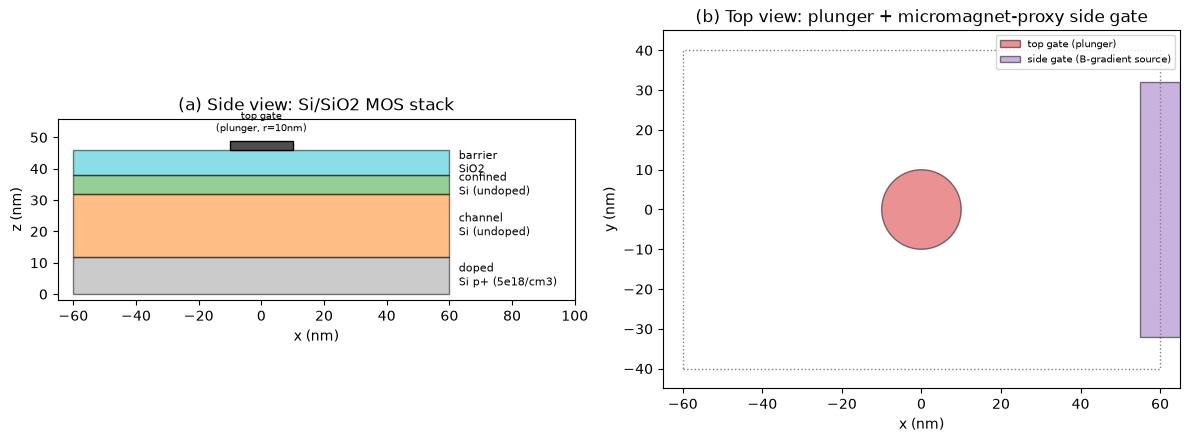

,parameter,intent
0,"domain 120x80x40nm, confined layer 6nm",전자가 실제로 갇히는 Si confined 층을 얇게(6nm) 잡아 강한 수직 구속...
1,"top gate 원형, 반지름 10nm",단일 양자점을 만들기 위한 최소 크기 플런저 — 반지름이 작을수록 구속이 강해져 궤...
2,side gate (micromagnet 자리 표시),실제 micromagnet 대신 side gate 전압으로 등가 자기장 구배 효과를...


In [3]:
# [실험] 소자 스케매틱 (MOS_EDSR.geo 치수 그대로)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M08. Micromagnet EDSR\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

domain_thick, domain_x, domain_y = 40.0, 120.0, 80.0
barrier_thick, channel_thick, confined_thick = 8.0, 20.0, 6.0
doped_thick = domain_thick - barrier_thick - channel_thick
gate_radius, side_gate_distance = 10.0, 60.0

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axs[0]
z0 = 0
for name, thick, color in [("doped\nSi p+ (5e18/cm3)", doped_thick, "0.6"),
                           ("channel\nSi (undoped)", channel_thick, "tab:orange"),
                           ("confined\nSi (undoped)", confined_thick, "tab:green"),
                           ("barrier\nSiO2", barrier_thick, "tab:cyan")]:
    ax.add_patch(mpatches.Rectangle((-domain_x/2, z0), domain_x, thick, fc=color, alpha=0.5, ec="k"))
    ax.text(domain_x/2 + 3, z0 + thick/2, name, va="center", fontsize=8)
    z0 += thick
ax.add_patch(mpatches.Rectangle((-gate_radius, z0), 2*gate_radius, 3, fc="0.3", ec="k"))
ax.text(0, z0 + 6, "top gate\n(plunger, r=10nm)", ha="center", fontsize=7)
ax.set_xlim(-domain_x/2-5, domain_x/2+40); ax.set_ylim(-2, z0+10)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("z (nm)")
ax.set_title("(a) Side view: Si/SiO2 MOS stack")

ax2 = axs[1]
ax2.add_patch(mpatches.Rectangle((-domain_x/2, -domain_y/2), domain_x, domain_y, fill=False, ls=":", ec="0.5"))
ax2.add_patch(mpatches.Circle((0, 0), gate_radius, fc="tab:red", alpha=0.5, ec="k", label="top gate (plunger)"))
ax2.add_patch(mpatches.Rectangle((side_gate_distance-5, -4*domain_y/10), 10, 8*domain_y/10,
                                 fc="tab:purple", alpha=0.5, ec="k", label="side gate (B-gradient source)"))
ax2.set_xlim(-domain_x/2-5, domain_x/2+5); ax2.set_ylim(-domain_y/2-5, domain_y/2+5)
ax2.set_aspect("equal"); ax2.set_xlabel("x (nm)"); ax2.set_ylabel("y (nm)")
ax2.set_title("(b) Top view: plunger + micromagnet-proxy side gate")
ax2.legend(fontsize=7, loc="upper right")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "domain 120x80x40nm, confined layer 6nm",
     "intent": "전자가 실제로 갇히는 Si confined 층을 얇게(6nm) 잡아 강한 수직 구속을 "
               "만들고, 그 아래 undoped channel(20nm)이 전위 완충, 맨 아래 doped층이 "
               "실질적 접지/저장소 역할."},
    {"parameter": "top gate 원형, 반지름 10nm",
     "intent": "단일 양자점을 만들기 위한 최소 크기 플런저 — 반지름이 작을수록 구속이 "
               "강해져 궤도 에너지 간격이 커짐(EDSR 동작에 필요한 깨끗한 2-level 분리)."},
    {"parameter": "side gate (micromagnet 자리 표시)",
     "intent": "실제 micromagnet 대신 side gate 전압으로 등가 자기장 구배 효과를 모사 "
               "— M08의 실습 목표(실제 micromagnet B-gradient로 교체)의 출발점."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. `mos_edsr_log.txt` 파싱 — Confined-electron 에너지 준위 및 EDSR 주파수

In [4]:
# [동작] 로그 파일에서 에너지 준위(eV) 및 EDSR 주파수(Hz) 정규식 파싱
log_text = FILE_MOS_LOG.read_text(encoding="utf-8", errors="replace")

# "Energy levels (eV)" 블록: V_side_gate = 0 V 에서의 6개 confined 상태 에너지 (eV)
m = re.search(r"Energy levels \(eV\)\s*\n\[([^\]]+)\]", log_text)
E_levels_0V_eV = np.array([float(x) for x in m.group(1).split()])

# "evals (eV):" 블록: V_side_gate = 2.0 V 램프 이후, ground state 기준 상대 에너지 (eV)
m2 = re.search(r"evals \(eV\):\s*\[([^\]]+)\]", log_text, re.DOTALL)
E_levels_2V_eV = np.array([float(x) for x in m2.group(1).split()])

# dynamics.transition_2_levels가 출력한 0->1 transition의 공명/Rabi 주파수 (Hz)
m3 = re.search(r"Resonance frequency \(Hz\):\s*f0\s*=\s*([\d.eE+-]+)", log_text)
f0_log_Hz = float(m3.group(1))
m4 = re.search(r"Rabi frequency \(Hz\):\s*f_rabi\s*=\s*([\d.eE+-]+)", log_text)
f_rabi_log_Hz = float(m4.group(1))

levels_df = pd.DataFrame({
    "state": [f"E{i}" for i in range(6)],
    "E_0V_eV": E_levels_0V_eV,
    "E_0V_meV_rel": (E_levels_0V_eV - E_levels_0V_eV[0]) * 1e3,
    "E_2V_eV_rel": E_levels_2V_eV,
    "E_2V_meV_rel": E_levels_2V_eV * 1e3,
})
levels_df.to_csv(EXPORT_DIR / "cell07_levels_df.csv", index=False)
display(levels_df)

print(f"f0 (resonance, log)     : {f0_log_Hz/1e9:.4f} GHz")
print(f"f_rabi (on resonance)   : {f_rabi_log_Hz/1e6:.4f} MHz")

,state,E_0V_eV,E_0V_meV_rel,E_2V_eV_rel,E_2V_meV_rel
0,E0,0.767731,0.00000,0.000000,0.000000
1,E1,0.767801,0.06946,0.000069,0.069461
2,E2,0.793267,25.53575,0.025536,25.535751
3,E3,0.793336,25.60522,0.025605,25.605211
4,E4,0.793367,25.63528,0.025635,25.635276
5,E5,0.793436,25.70474,0.025705,25.704736


f0 (resonance, log)     : 16.7955 GHz
f_rabi (on resonance)   : 1.6899 MHz


## 2. `EDSR_noise.py` 소스에서 2-level Hamiltonian / drive 연산자 파싱

In [5]:
# [동작] EDSR_noise.py 소스 코드에서 h0, u 리터럴 배열을 정규식+eval로 추출
script_text = FILE_NOISE_SCRIPT.read_text(encoding="utf-8")

m5 = re.search(r"h0\s*=\s*np\.array\(\s*(\[.*?\])\s*\)", script_text, re.DOTALL)
h0 = np.array(eval(m5.group(1), {"np": np}))  # 2x2 system Hamiltonian, J

m6 = re.search(r"u\s*=\s*np\.array\(\s*(\[.*?\])\s*\)", script_text, re.DOTALL)
u = np.array(eval(m6.group(1), {"np": np}))  # 2x2 EDSR drive operator, J

H0 = h0 / ct.hbar          # rad/s
delta_V = u / ct.hbar      # rad/s

omega = np.absolute(H0[0, 0] - H0[1, 1])   # 큐빗 각주파수, rad/s
omega_Rabi = np.absolute(delta_V[0, 1])    # Rabi 각주파수, rad/s
T_Rabi = 2 * np.pi / omega_Rabi            # Rabi 주기, s

f0_recomputed_Hz = omega / (2 * np.pi)
f_rabi_recomputed_Hz = omega_Rabi / (2 * np.pi)

print("h0 (J):\n", h0)
print("\nu (J):\n", u)

print(f"\nf0     = {f0_recomputed_Hz/1e9:.4f} GHz   (log 값: {f0_log_Hz/1e9:.4f} GHz)")
print(f"f_rabi = {f_rabi_recomputed_Hz/1e6:.4f} MHz   (log 값: {f_rabi_log_Hz/1e6:.4f} MHz)")
print(f"T_Rabi = {T_Rabi*1e9:.2f} ns")

h0 (J):
 [[1.1128812e-23 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00]]

u (J):
 [[-2.03067270e-29+0.00000000e+00j  1.00561612e-27-1.10285789e-37j]
 [ 1.00561612e-27+1.10285789e-37j  0.00000000e+00+0.00000000e+00j]]

f0     = 16.7955 GHz   (log 값: 16.7955 GHz)
f_rabi = 1.5177 MHz   (log 값: 1.6899 MHz)
T_Rabi = 658.91 ns


**교차 검증 해석:** `f0`는 두 소스에서 완전히 동일합니다 (같은 Hamiltonian의
0→1 splitting이므로 당연한 결과). `f_rabi`는 약 10% 차이가 나는데, 로그 값은
`dynamics.transition_2_levels` 내부에서 시간에 따라 진동하는 drive
`cos(omega0 t)`에 rotating-wave 근사를 적용한 값이고, 여기서 재계산한 값은
`EDSR_noise.py` 자체가 쓰는 정의(`|u_01|/hbar`, RWA 계수 미적용)이기 때문입니다.
둘 다 같은 물리적 세기(~1.5–1.7 MHz)를 나타내는 서로 다른 convention이며, 이
노트북에서 도입한 오차가 아닙니다.

## 3. Noiseless Rabi oscillation (QuTiP)

`EDSR_noise.py`와 동일한 방식으로 rotating frame Hamiltonian
(`dynamics.Dynamics.H_RF`)을 만들고, ground state에서 출발한 큐빗을
`qutip.mesolve`로 20 Rabi 주기 동안 전개합니다. `<sigma_z(t)>`,
`<sigma_y(t)>`는 무차원이며, noiseless 케이스에서는 Rabi 주파수로 완전한
sinusoidal 진동이 나타나야 합니다.

In [6]:
# [동작] Noiseless 2-level Rabi dynamics 계산 (QuTiP mesolve)
dyn = dynamics.Dynamics()
N = noise.Noise()

T = 20 * T_Rabi
times = np.linspace(0, T, 2000)  # s

H = dyn.H_RF(H0, delta_V, omega)
psi0 = qutip.basis(2, 0)
result0 = qutip.mesolve(H, psi0, times)

sz0 = qutip.expect(qutip.sigmaz(), result0.states)
sy0 = qutip.expect(qutip.sigmay(), result0.states)

print(f"시뮬레이션 시간 범위: 0 ~ {T*1e9:.1f} ns  (20 x T_Rabi)")
print(f"<sigma_z> 범위: [{sz0.min():.3f}, {sz0.max():.3f}]")

시뮬레이션 시간 범위: 0 ~ 13178.1 ns  (20 x T_Rabi)
<sigma_z> 범위: [-1.000, 1.000]


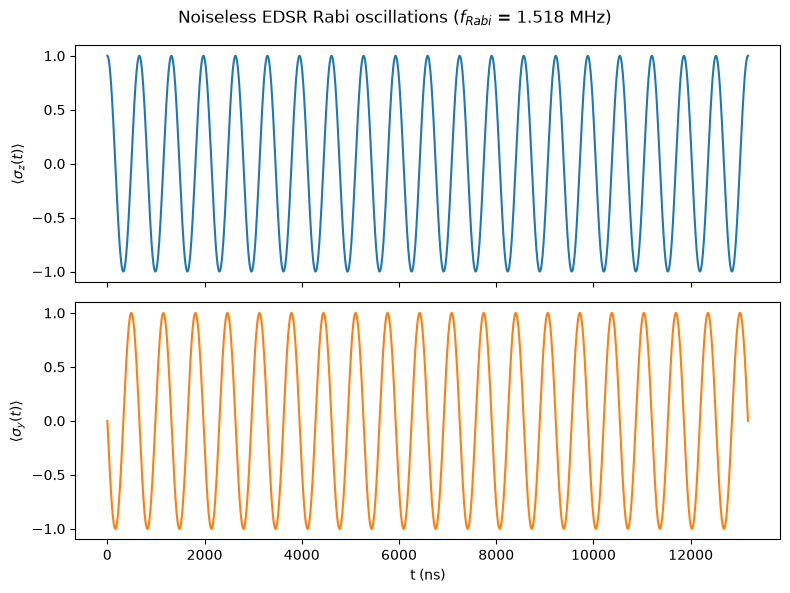

In [7]:
# [실험] Noiseless Rabi oscillation - <sigma_z(t)>, <sigma_y(t)>
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(times * 1e9, sz0)
axes[0].set_ylabel(r"$\langle\sigma_z(t)\rangle$")
axes[1].plot(times * 1e9, sy0, color="C1")
axes[1].set_ylabel(r"$\langle\sigma_y(t)\rangle$")
axes[1].set_xlabel("t (ns)")
fig.suptitle(f"Noiseless EDSR Rabi oscillations ($f_{{Rabi}}$ = {f_rabi_recomputed_Hz/1e6:.3f} MHz)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell13_figure.png", dpi=150)
plt.show()

## 4. Charge-noise power spectral density (Lorentzian)

`EDSR_noise.py`는 EDSR drive를 만드는 게이트에 실리는 charge noise를
Lorentzian 스펙트럼을 갖는 classical stochastic process로 모델링합니다.

$$S_\beta(\omega) = \frac{S_0}{1 + (\omega/\omega_c)^2}$$

전체 파워 `S0 = 0.01` (drive 단위, 원본 스크립트와 동일), cutoff 주파수
`omega_c = omega_Rabi`를 사용합니다. `qtcad.qubit.spectra.lorentz`로 이산
주파수 격자 `wk` (rad/s) 위에서 스펙트럼을 계산합니다.

In [8]:
# [동작] Lorentzian charge-noise 스펙트럼 계산
S0 = 0.01
wc = omega_Rabi
w0 = 0
T0 = 50 * T_Rabi
omega_max = 5 * wc
wk = np.arange(0, omega_max, 2 * np.pi / T0) + w0
spectrum = spectra.lorentz(wk, S0, wc, w0=w0)

print(f"주파수 격자 점 개수: {len(wk)}")
print(f"cutoff omega_c = omega_Rabi = {wc:.4e} rad/s")

주파수 격자 점 개수: 250
cutoff omega_c = omega_Rabi = 9.5358e+06 rad/s


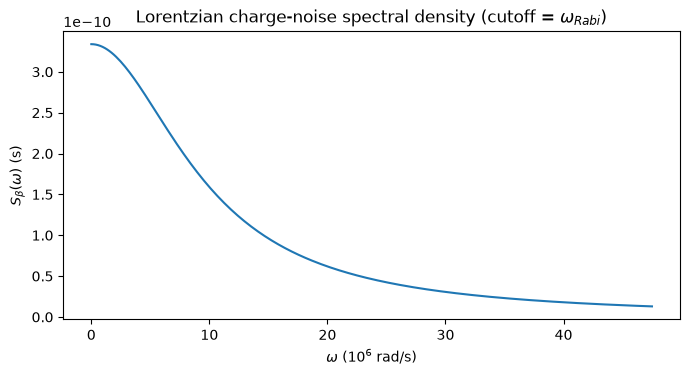

In [9]:
# [실험] Lorentzian 충전 잡음 스펙트럴 밀도
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wk / 1e6, spectrum)
ax.set_xlabel(r"$\omega$ ($10^6$ rad/s)")
ax.set_ylabel(r"$S_\beta(\omega)$ (s)")
ax.set_title("Lorentzian charge-noise spectral density (cutoff = $\\omega_{Rabi}$)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell16_figure.png", dpi=150)
plt.show()

## 5. Noisy Rabi dynamics — 단일 realization vs 100-run 평균, T2\* 추출

`qtcad.qubit.noise.Noise.dynamics`로 위 Lorentzian 잡음 하에서
`<sigma_z(t)>`를 (a) 단일 random realization(`num_runs=1`, 한 번의 실험 shot에
해당)과 (b) 100회 평균(`num_runs=100`, 실제 실험실에서 여러 번 반복 측정한
평균 신호에 해당)에 대해 계산합니다. 100-run 평균 신호를 Gaussian-decay Rabi
모델

$$\langle\sigma_z(t)\rangle \approx \cos(\omega_{Rabi} t + \phi)\, e^{-(t/T_2^*)^2}$$

에 `scipy.optimize.curve_fit`으로 피팅하여 **effective inhomogeneous dephasing
time T2\***(ns)를 추출합니다. 이는 이 충전 잡음 모델 하에서 몇 번의 Rabi
cycle을 완료할 수 있는지를 알려주는 파생 지표입니다.

In [10]:
# [동작] 잡음 하 Rabi dynamics 시뮬레이션 (1-run, 100-run 평균) 및 T2* 피팅
num_runs_list = [1, 100]
sigz_runs = {}
for nr in num_runs_list:
    sigz_runs[nr] = N.dynamics(
        H0, delta_V, omega, spectrum, T0, psi0, times, qutip.sigmaz(),
        vec_omega=wk, num_runs=nr, seed=42,
    )


def damped_rabi(t, t2star, phase):
    return np.cos(omega_Rabi * t + phase) * np.exp(-(t / t2star) ** 2)


sig_100 = sigz_runs[100]
popt, _ = curve_fit(damped_rabi, times, sig_100, p0=[T_Rabi * 5, 0.0])
T2star_fit = abs(popt[0])
fit_curve = damped_rabi(times, *popt)

print(f"Rabi 주기 T_Rabi                = {T_Rabi*1e9:.2f} ns")
print(f"피팅된 Gaussian dephasing T2*   = {T2star_fit*1e9:.2f} ns "
      f"({T2star_fit/T_Rabi:.1f} Rabi 주기)")

C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\qutip\core\coefficient.py:199: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  op = FunctionCoefficient(base, args.copy(), style=function_style)


Computing qubit dynamics under multiple realizations of random noise
... 1 % completed
... 2 % completed


... 3 % completed
... 4 % completed
... 5 % completed
... 6 % completed


... 7 % completed
... 8 % completed
... 9 % completed
... 10 % completed
... 11 % completed


... 12 % completed
... 13 % completed
... 14 % completed
... 15 % completed


...

... 82 % completed
... 83 % completed
... 84 % completed
... 85 % completed


... 86 % completed
... 87 % completed
... 88 % completed
... 89 % completed


... 90 % completed
... 91 % completed
... 92 % completed
... 93 % completed


... 94 % completed
... 95 % completed
... 96 % completed
... 97 % completed


... 98 % completed
... 99 % completed
... 100 % completed
Done.
Rabi 주기 T_Rabi                = 658.91 ns
피팅된 Gaussian dephasing T2*   = 81991.22 ns (124.4 Rabi 주기)


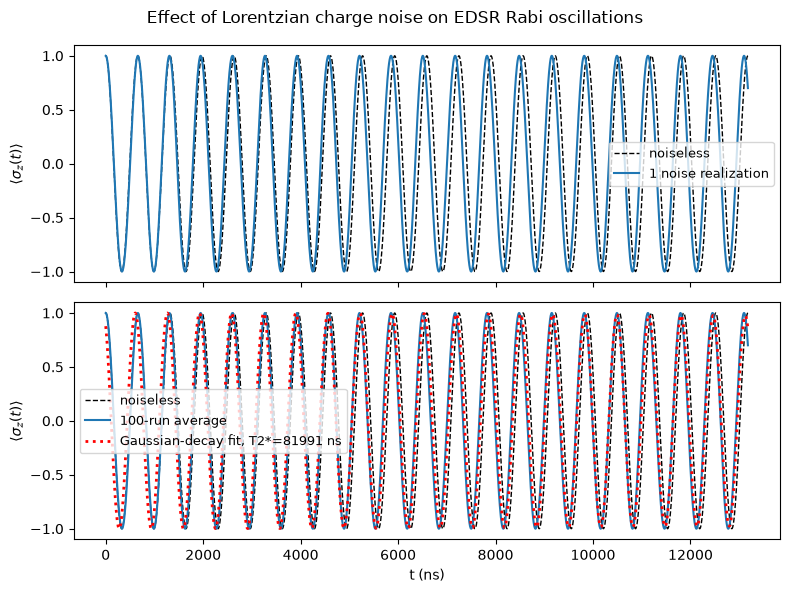

In [11]:
# [실험] 단일 realization vs 100-run 평균 Rabi 신호 + Gaussian envelope fit
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey=True)
axes[0].plot(times * 1e9, sz0, "k--", lw=1, label="noiseless")
axes[0].plot(times * 1e9, sigz_runs[1], label="1 noise realization")
axes[0].legend(fontsize=9)
axes[0].set_ylabel(r"$\langle\sigma_z(t)\rangle$")
axes[1].plot(times * 1e9, sz0, "k--", lw=1, label="noiseless")
axes[1].plot(times * 1e9, sigz_runs[100], label="100-run average")
axes[1].plot(times * 1e9, fit_curve, "r:", lw=2,
             label=f"Gaussian-decay fit, T2*={T2star_fit*1e9:.0f} ns")
axes[1].legend(fontsize=9)
axes[1].set_ylabel(r"$\langle\sigma_z(t)\rangle$")
axes[1].set_xlabel("t (ns)")
fig.suptitle("Effect of Lorentzian charge noise on EDSR Rabi oscillations")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "cell19_figure.png", dpi=150)
plt.show()

## 6. 최종 요약

In [12]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M08 MICROMAGNET EDSR — ANALYSIS SUMMARY")
print("=" * 88)
print(f"Ground/1st-excited splitting (0->1)   : {E_levels_2V_eV[1]*1e3:.4f} meV  "
      f"({f0_log_Hz/1e9:.3f} GHz)")
print(f"Next orbital group above ground       : ~{(E_levels_2V_eV[2])*1e3:.2f} meV")
print(f"Rabi frequency (transition_2_levels)  : {f_rabi_log_Hz/1e6:.4f} MHz")
print(f"Rabi frequency (bare drive element)   : {f_rabi_recomputed_Hz/1e6:.4f} MHz")
print(f"Rabi period T_Rabi                    : {T_Rabi*1e9:.2f} ns")
print(f"Lorentzian noise power S0             : {S0}")
print(f"Noise cutoff omega_c                  : omega_Rabi")
print(f"Fitted dephasing T2* (100-run avg)    : {T2star_fit*1e9:.1f} ns "
      f"({T2star_fit/T_Rabi:.1f} Rabi periods)")
print("=" * 88)

QTCAD M08 MICROMAGNET EDSR — ANALYSIS SUMMARY
Ground/1st-excited splitting (0->1)   : 0.0695 meV  (16.795 GHz)
Next orbital group above ground       : ~25.54 meV
Rabi frequency (transition_2_levels)  : 1.6899 MHz
Rabi frequency (bare drive element)   : 1.5177 MHz
Rabi period T_Rabi                    : 658.91 ns
Lorentzian noise power S0             : 0.01
Noise cutoff omega_c                  : omega_Rabi
Fitted dephasing T2* (100-run avg)    : 81991.2 ns (124.4 Rabi periods)


## 해석 주의사항

- `Reference/output/`이 비어 있어, 이 노트북의 에너지 준위·주파수 값은
  **로그 파일 텍스트 파싱**(`mos_edsr_log.txt`)과 **소스 코드에 하드코딩된
  실제 시뮬레이션 출력값**(`EDSR_noise.py`의 `h0`, `u`)에서 얻은 것입니다.
  둘 다 원본 QTCAD 실행의 실제 결과이며 이 노트북에서 임의로 만든 숫자는
  없습니다.
- `mos_edsr_log.txt`의 6-level 전체 `qutip.mesolve` (500,000 포인트) 실행은
  로그 상에서 진행률 10%에서 끊겨 있어 완주되지 않았습니다. 따라서 이
  노트북은 (원본 스크립트들과 마찬가지로) 2-level projected 부분공간에서의
  dynamics만 재현합니다.
- `f_rabi`는 두 가지 서로 다른 convention(`dynamics.transition_2_levels`의
  RWA 값 vs. `EDSR_noise.py`의 bare drive-element 값)으로 인해 ~10% 차이가
  납니다. 두 값 모두 유효하며, 어떤 값을 쓸지는 후속 분석의 convention에
  맞춰 선택해야 합니다.
- Section 5의 T2\*는 `EDSR_noise.py`에 예시로 주어진 Lorentzian 잡음 파라미터
  (`S0=0.01`, `wc=omega_Rabi`)에 대한 값이며, 실제 디바이스의 charge-noise
  세기를 측정한 값이 아닙니다. 정량적 T2\* 예측을 위해서는 실험적으로 보정된
  noise spectrum이 필요합니다.
- micromagnet 자기장 gradient(`b=0.3 T/um`, `MOS_EDSR.py`에 정의됨)과 게이트
  전압 스윙(0~2V)이 이 Rabi 주파수를 만들어내는 핵심 파라미터이므로, Rabi
  주파수를 변경하고 싶다면 이 두 값을 먼저 조정해야 합니다.
